In [1]:
from frb.galaxies import galfit
from frb.frb import FRB
from frb.galaxies.frbgalaxy import FRBHost

from astropy.io import fits
from astropy import visualization as vis, units as u
from astropy.stats import sigma_clipped_stats
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.table import Table

import numpy as np
import matplotlib.pyplot as plt

from photutils.isophote import Ellipse
from photutils.isophote import EllipseGeometry
from photutils.isophote import build_ellipse_model
from photutils.aperture import SkyEllipticalAperture, SkyEllipticalAnnulus, EllipticalAnnulus, EllipticalAperture
from photutils.segmentation import SourceFinder, SourceCatalog

import os

%matplotlib inline
plt.rcParams['font.size'] = 16

## Loading FRB information

In [2]:
frb = FRB.by_name("FRB20190608B").grab_host()
frb_pos = FRB.by_name("FRB20190608B").coord
posellipse = FRB.by_name("FRB20190608B").eellipse
posellipse

{'a': 0.19,
 'a_sys': 0.33,
 'b': 0.18,
 'b_sys': 0.3,
 'cl': 68.0,
 'cl_sys': 68.0,
 'theta': 90.0,
 'theta_sys': 90.0}

## Examine image at hand 

In [ ]:
hdulist = fits.open("../data/FRB190608_F160W_drz_sci.fits")
hdulist.info()

Filename: /home/sunil/Desktop/FRB/GALFIT/F160W_30mas/FRB190608_F160W_drz_sci.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     933   (2232, 1976)   float32   
  1  HDRTAB        1 BinTableHDU    559   7R x 275C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 2A, 9A, 7A, 18A, D, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, D, 3A, D, D, D, D, K, K, 8A, 23A, 11A, 18A, 4A, D, D, K, K, D, D, D, D, 23A, D, D, D, D, K, K, D, 3A, 8A, L, D, D, D, 23A, 1A, D, D, D, D, D, D, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 2A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, D, D, D, 4A, 18A, 3A, K, 5A, D, D, D, 8A, D, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, 8A, 23A, K, K, 10A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 13A, D, 24A, 23A, D, 1A, 1A, D, K, D, D, 1A, 1A, D, D, D, D, D, D, D, D, D, D, D, 4A, D, K, 23A, D, 8A, D, D, 13A, D, D, L, D, D, 5A, 9A, 2A

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


0.2985109 0.012548865


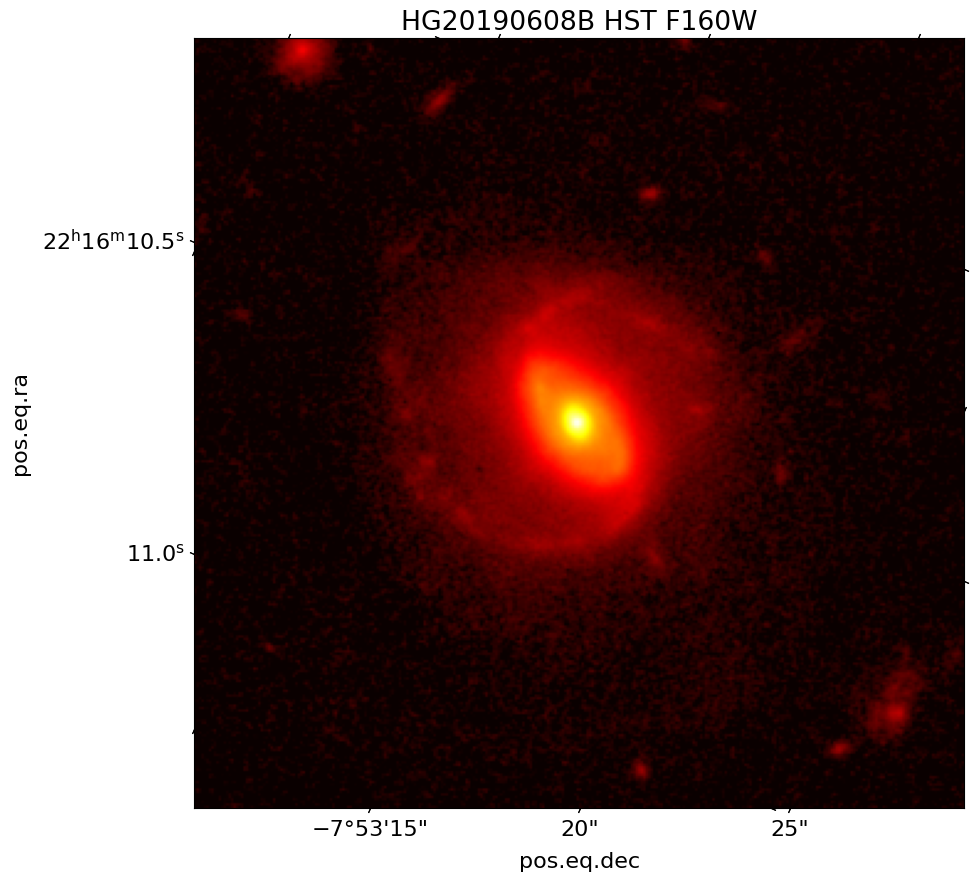

In [ ]:
hdulist = fits.open("../data/FRB190608_F160W_drz_sci.fits")
wcs = WCS(hdulist[0].header)
cutout = Cutout2D(hdulist[0].data, frb.coord, 20*u.arcsec, wcs)
_, med, std = sigma_clipped_stats(cutout.data)
print(med, std)
cutout.data -= med # Subtract sky
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(projection=wcs)
ax.imshow(cutout.data, cmap="hot",
          norm=vis.ImageNormalize(stretch=vis.LogStretch(), vmin = med-24*std, vmax = med+ 3000*std))
ax.set_title("HG20190608B HST F160W")
#ax.grid(ls="--", lw = 1, color="grey")
plt.show()

## Creating a mask to exclude non-host sources

### Source identification and image segementation

In [7]:
# Create segmentaiton map for badpix
finder = SourceFinder(npixels=25, progress_bar=False, deblend = False, relabel = True, connectivity=4, contrast=0.01)
segmap = finder(cutout.data, threshold = 3*std)
objects = SourceCatalog(cutout.data, segmap).to_table()

In [8]:
objects

label,xcentroid,ycentroid,sky_centroid,bbox_xmin,bbox_xmax,bbox_ymin,bbox_ymax,area,semimajor_sigma,semiminor_sigma,orientation,eccentricity,min_value,max_value,local_background,segment_flux,segment_fluxerr,kron_flux,kron_fluxerr
,,,,,,,,pix2,pix,pix,deg,,,,,,,,
int32,float64,float64,object,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,477.2288888560663,1.9000606931546562,None,463,489,0,5,105.0,7.076760375102502,1.4513416011406746,2.0294642110986603,0.978744041802818,0.023783445358276367,0.0493205189704895,0.0,3.3877817690372467,nan,7.506182292931183,nan
2,58.25909314871692,16.511939949898807,None,50,65,9,23,139.0,3.4722446276149643,2.5553772610576675,-43.63364967676707,0.6770425190765812,0.02334997057914734,0.13350209593772888,0.0,6.7148683071136475,nan,10.400654340757548,nan
3,826.8578427804952,24.962448657963424,None,822,832,18,31,87.0,2.6682363914075546,2.0555652567613514,-81.47381211777349,0.637580804403947,0.02388063073158264,0.17419102787971497,0.0,4.233725339174271,nan,8.53804587783102,nan
4,716.7252486956546,40.91353754824191,None,706,728,30,54,325.0,4.823569781508641,3.480980625292798,-31.17454546813288,0.6922469717530816,0.02351313829421997,0.4081368148326874,0.0,25.665451735258102,nan,32.75170351255784,nan
5,391.59969083065533,41.99008332583051,None,382,401,33,52,234.0,3.3960568088688863,2.990257526208624,-70.56578566166792,0.4740300093959113,0.023428916931152344,0.6842150688171387,0.0,20.30595377087593,nan,24.645206159539242,nan
6,137.00387237254304,50.815375568679016,None,132,142,47,54,51.0,2.6806870093990707,1.339605804424495,-24.86401218506209,0.8661842269531583,0.023454755544662476,0.07464417815208435,0.0,2.226878196001053,nan,3.685240527421914,nan
7,928.5834114460941,87.26649204865694,None,923,934,82,93,89.0,2.8525471991888867,2.0594180545603544,23.0062507853502,0.6919373251198615,0.023453980684280396,0.11575236916542053,0.0,4.175649583339691,nan,6.989234572589465,nan
8,700.335767287153,108.89005537370726,None,693,707,99,117,196.0,3.82372359621975,2.8787628161129586,77.7146844996257,0.6581704380811895,0.023372739553451538,0.20438605546951294,0.0,13.10809126496315,nan,17.926637739207614,nan


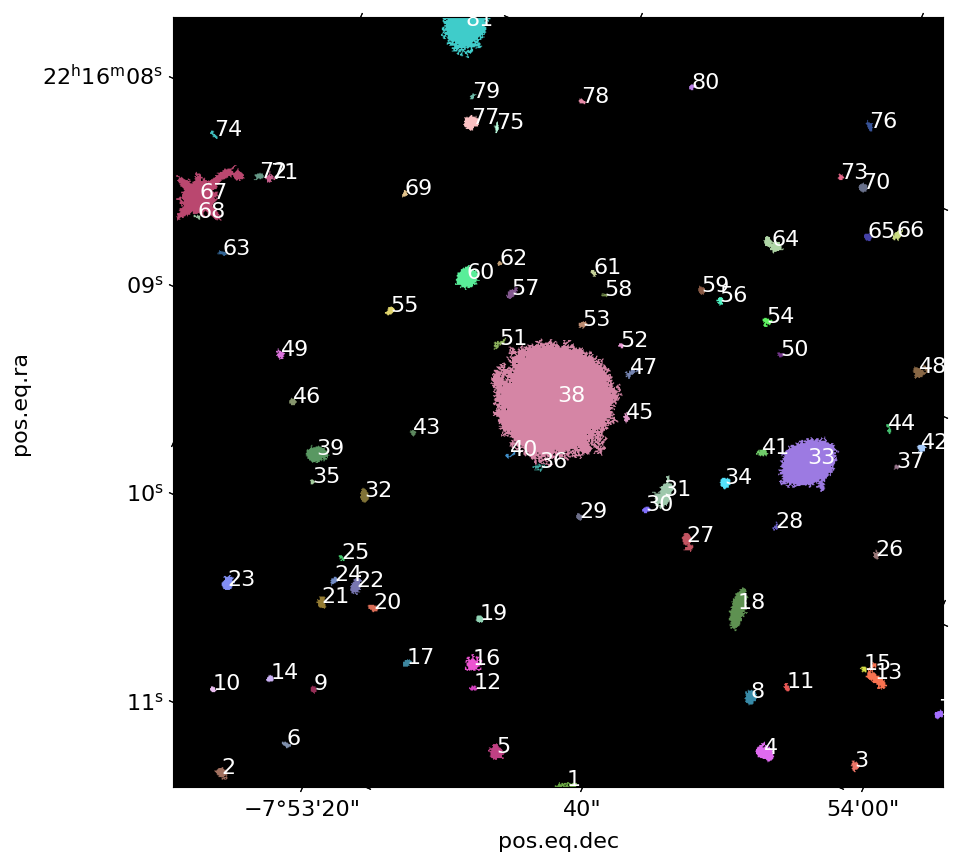

In [9]:
plt.figure(figsize=(10,10))
ax = plt.subplot(projection=wcs)
ax.imshow(segmap, cmap=segmap.cmap)
for idx, obj in enumerate(objects):
    ax.annotate(str(idx+1),(obj['xcentroid'],obj['ycentroid']),color="white")

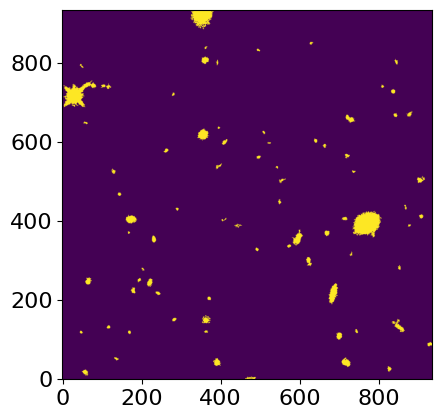

In [10]:
newsegmap = segmap.data.copy()
maskout = newsegmap==38
newsegmap[maskout] = 0

# bad pixels should have value of 1
newsegmap[newsegmap>0] = 1

plt.imshow(newsegmap)
plt.gca().invert_yaxis()

# save segmap as a fits file
hdu = fits.PrimaryHDU(newsegmap, cutout.wcs.to_header())
hdulist = fits.HDUList([hdu])
hdulist.writeto("../data/Morphology/badpix_190608.fits", overwrite=True)

In [12]:
psfhdus = fits.open("../data/Morphology/FRB190608_f160w_psf.fits")
psfhdus[0].header

SIMPLE  =                    T                                                  
BITPIX  =                  -32                                                  
NAXIS   =                    2                                                  
NAXIS1  =                  414                                                  
NAXIS2  =                  414                                                  
EXTEND  =                    F                                                  
CREATED = 'Fri Aug  7 18:02:37 2020'  / Time and date file was created          
INSTRUME= 'WFC3_IR'            / Simulated instrument                           
FOCUS   =              -0.0631 / PSF RMS focus (waves @ 547 nm)                 
X_COMA  =              -0.0262 / PSF RMS X-coma (waves @ 547 nm)                
Y_COMA  =               0.0501 / PSF RMS Y-coma (waves @ 547 nm)                
X_ASTIG =              -0.0509 / PSF RMS 0d astig (waves @ 547 nm)              
Y_ASTIG =              -0.00

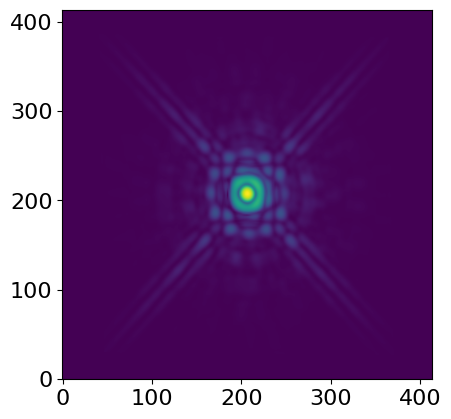

In [14]:
plt.imshow(psfhdus[0].data, norm=vis.ImageNormalize(stretch=vis.LogStretch()))
plt.gca().invert_yaxis()
plt.show()

In [15]:
help(galfit.run)

Help on function run in module frb.galaxies.galfit:

run(imgfile: str, psffile: str = None, **kwargs) -> int
    Run galfit.

    Args:
        imgfile (str): path to the image fits file.
        psffile (str): path to the PSF model fits file.

    Valid kwargs:
        mode (int, optional): 0=optimize, 1=model, 2=imgblock, 3=subcomps.
            Which mode would you like galfit to run in?
        outdir (str): Name of output directory. Default
            value is 'galfit_out` in the current directory.
        configfile (str, optional): path to configuration file to
            be created via this function. Defaults to `<outdir>/galfit.feedme`.
        cdkfile (str, optional): Path to the charge diffusion kernel
            file. Useful is you have oversampled HST PSFs from
            Tiny Tim.
        outfile (str, optional): path to GALFIT's output fits file.
            Defaults to `<outdir>/out.fits`
        noisefile (str, optional): If you'd like to use an
            image n

In [16]:
galfit.run(imgfile="../data/Morphology/FRB190608_cutout.fits",
           psffile="../data/Morphology/FRB190608_f160w_psf.fits", cdkfile= "../data/Morphology/190608_CDK.txt",outdir="../data/Morphology/F160W_190608",finesample=9,
           badpix = "../data/Morphology/badpix_190608.fits",
           r_e = 50, n = 4, axis_ratio = 0.6, convobox = (300, 300))

/home/sunil/Python/FRB/frb/galaxies/galfit.py:163: UserWarning: Creating a configuration file here
  warnings.warn("Creating a configuration file here")
/home/sunil/Python/FRB/frb/galaxies/galfit.py:190: UserWarning: Creating output file here
  warnings.warn("Creating output file here")
/home/sunil/Python/FRB/frb/galaxies/galfit.py:210: UserWarning: Using full region to fit. May fail if other objects in the region aren't masked.
  warnings.warn("Using full region to fit. May fail if other objects in the region aren't masked.")
/home/sunil/Python/FRB/frb/galaxies/galfit.py:244: UserWarning: No guess given for integrated magnitude. Proceeding with sum within region.
  warnings.warn("No guess given for integrated magnitude. Proceeding with sum within region.")



GALFIT Version 3.0.5 -- Apr. 23, 2013




#  Input menu file: galfit.feedme


# IMAGE and GALFIT CONTROL PARAMETERS
A) /home/sunil/Python/ftsky_optical/data/Morphology/FRB190608_cutout.fits      # Input data image (FITS file)
B) out.fits            # Output data image block
C) None                # Sigma image name (made from data if blank or "none") 
D) psffile.fits cdkfile.txt # Input PSF image and (optional) diffusion kernel
E) 9                   # PSF fine sampling factor relative to data 
F) /home/sunil/Python/ftsky_optical/data/Morphology/badpix_190608.fits      # Bad pixel mask (FITS image or ASCII coord list)
G) none                # File with parameter constraints (ASCII file) 
H) 0    311  0    311  # Image region to fit (xmin xmax ymin ymax)
I) 300    300          # Size of the convolution box (x y)
J) 25.000              # Magnitude photometric zeropoint 
K) 0.064  0.064        # Plate scale (dx dy)   [arcsec per pixel]
O) regular             # Display type (regular, curs

0

In [23]:
ls

cdkfile.txt*  fit.log  galfit.01  galfit.feedme  out.fits  psffile.fits*


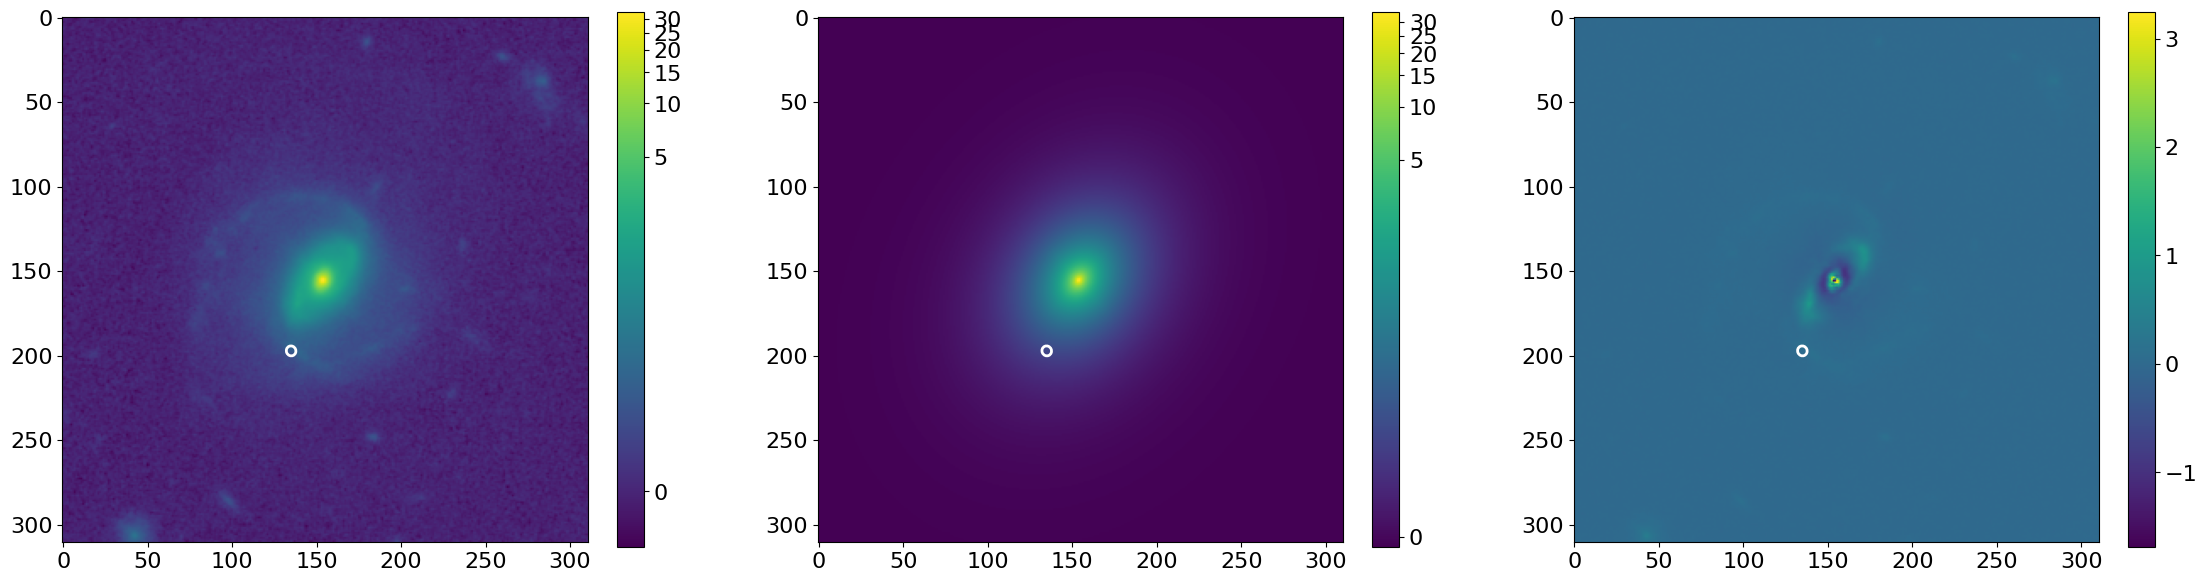

In [19]:
plt.rcParams['font.size'] = 16
hdulist = fits.open("out.fits")
skyerr_ell = SkyEllipticalAperture(frb_pos, posellipse['a']*u.arcsec, posellipse['b']*u.arcsec,theta=posellipse['theta']*u.deg)
err_ell = skyerr_ell.to_pixel(WCS(hdulist[1].header))
apermask = err_ell.to_mask()
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(27,9),gridspec_kw={'wspace':0.3})
labels = ['HST WFC3 F160W','Fit','Residuals']
for (num,hdu),ax,label in zip(enumerate(hdulist[1:4]),axs,labels):
    if num==2:
        norm = vis.ImageNormalize(stretch=vis.LinearStretch())
    else:
        norm = vis.ImageNormalize(stretch=vis.LogStretch())
    im = ax.imshow(hdu.data, norm=norm)
    err_ell.plot(ax, color="w", lw=2)
    fig.colorbar(im, ax=ax, fraction=0.046)

In [36]:
from photutils.isophote import Ellipse
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture
from photutils.isophote import build_ellipse_model

geometry = EllipseGeometry(x0=150, y0=150, sma=50, eps=0.6, pa=-28.9*np.pi/180.)
ellipse = Ellipse(cutout.data, geometry)
isolist = ellipse.fit_image(maxsma=150,sclip=3.,nclip=10,step = 0.05)
model_image = build_ellipse_model(cutout.data.shape, isolist)
residual = cutout.data - model_image

/home/sunil/miniconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sunil/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/sunil/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/sunil/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/sunil/miniconda3/lib/python3.12/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


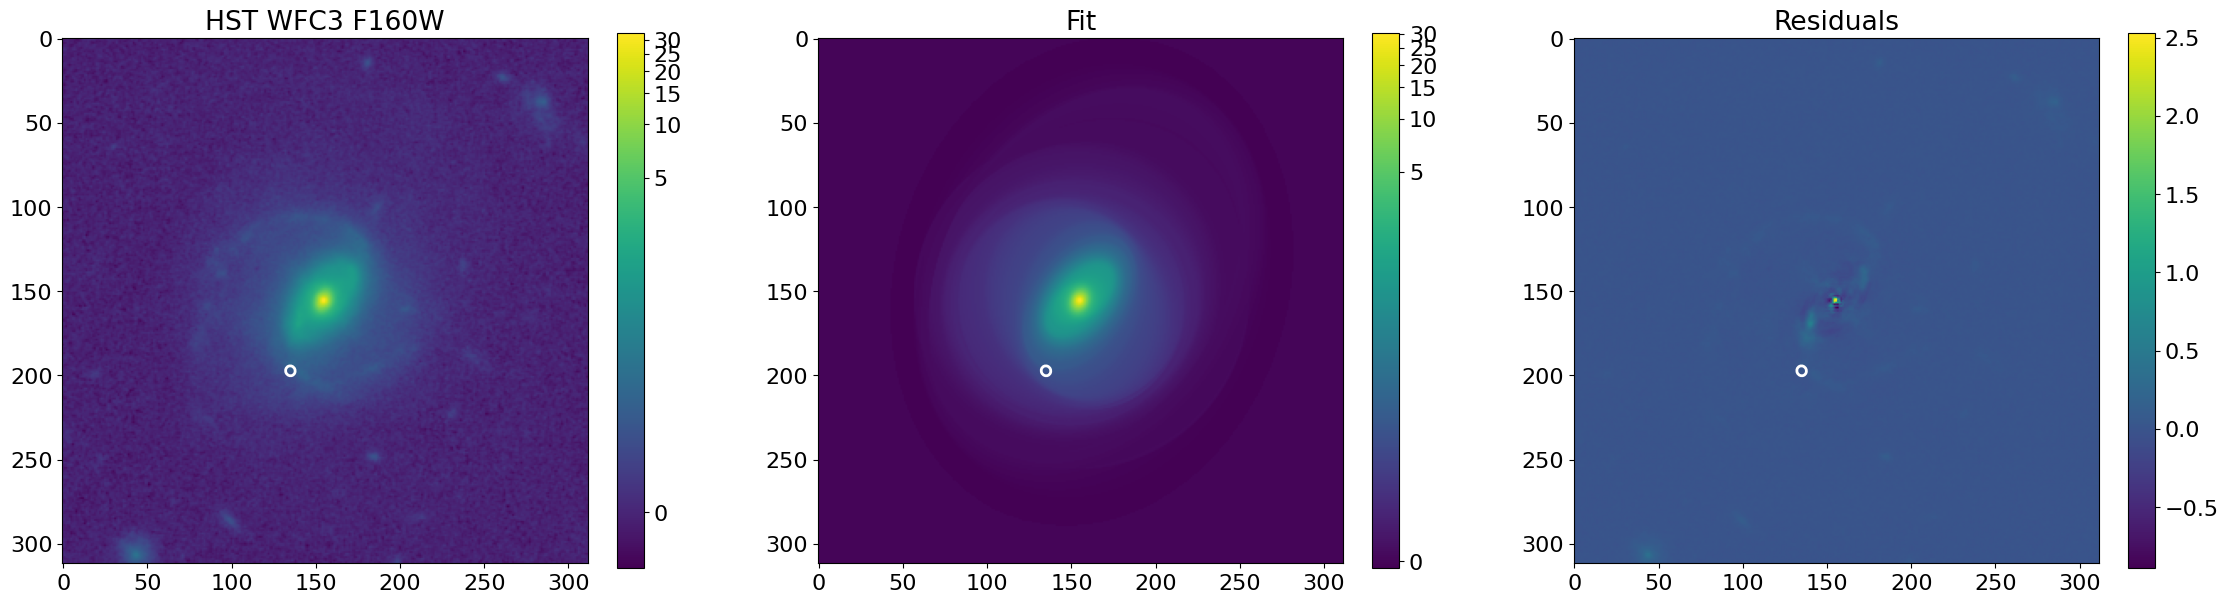

In [37]:
ell_ims = [cutout.data, model_image, residual]
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(27,9),gridspec_kw={'wspace':0.3})
for pic, ax, label in zip(ell_ims,axs, labels):
    _, med, std = sigma_clipped_stats(pic)
    if np.all(pic == residual):
        im = ax.imshow(pic, norm=vis.ImageNormalize(stretch=vis.LinearStretch()))
    else:
        im = ax.imshow(pic, norm=vis.ImageNormalize(stretch=vis.LogStretch()))
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(label)
    err_ell.plot(ax, color="w", lw=2)